In [2]:
# Import libraries for data handling
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing library
from sklearn.preprocessing import StandardScaler

# DBSCAN clustering algorithm
from sklearn.cluster import DBSCAN

# Hierarchical clustering tools
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering

In [3]:
# Upload dataset from your computer into Google Colab
# Read the dataset
df = pd.read_csv("spotify_tracks.csv")

# Display first 5 rows
df.head()

,track_id,track_name,artist_name,album_name,release_year,genre,popularity,duration_ms,explicit,danceability,...,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,key,mode,time_signature
0,P3fAbnFbmOHnKYaXRvj7uf,One Dance (Acoustic Version),Alex Rodriguez,The Night Album,2024,metal,14,189042,True,0.427723,...,-4.702460,0.050635,0.239506,0.181395,0.133053,0.431384,141.048735,6,0,4
1,M2wleOV911xCZkwPRQeNHp,Forever Song (Remix),Desert Wind,Burning Soul,2019,rock,11,186805,True,0.448634,...,-7.110031,0.000000,0.044463,0.097818,0.435949,0.559135,131.833287,0,1,5
2,4JSnE2NiiUHUAKw9iEU1jj,Last Mountain,The Midnight,The Night Album,2022,k-pop,23,121814,False,0.707923,...,-7.305120,0.144091,0.118380,0.000000,0.262254,0.516873,127.132954,2,1,5
3,2UVvsjaSS8VFgM0Fmxk754,Falling Star (Live),Phantom Keys,Phantom's Greatest Hits,2024,latin,34,216049,False,0.846237,...,-9.527256,0.006668,0.272844,0.000000,0.045332,0.667911,93.041715,0,1,6
4,EeVVhDIq2AnHTmt9OBGhnu,Rising Moon (feat. someone),Desert Wind,Rising Soul,2010,latin,31,156170,False,0.943720,...,-9.017653,0.057632,0.219752,0.098044,0.132083,0.772151,93.404975,7,1,4


In [4]:
# Check dataset structure and data types
df.info()

# Show first few rows again
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          50000 non-null  object 
 1   track_name        50000 non-null  object 
 2   artist_name       50000 non-null  object 
 3   album_name        50000 non-null  object 
 4   release_year      50000 non-null  int64  
 5   genre             50000 non-null  object 
 6   popularity        50000 non-null  int64  
 7   duration_ms       50000 non-null  int64  
 8   explicit          50000 non-null  bool   
 9   danceability      50000 non-null  float64
 10  energy            50000 non-null  float64
 11  loudness          50000 non-null  float64
 12  speechiness       50000 non-null  float64
 13  acousticness      50000 non-null  float64
 14  instrumentalness  50000 non-null  float64
 15  liveness          50000 non-null  float64
 16  valence           50000 non-null  float6

,track_id,track_name,artist_name,album_name,release_year,genre,popularity,duration_ms,explicit,danceability,...,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,key,mode,time_signature
0,P3fAbnFbmOHnKYaXRvj7uf,One Dance (Acoustic Version),Alex Rodriguez,The Night Album,2024,metal,14,189042,True,0.427723,...,-4.702460,0.050635,0.239506,0.181395,0.133053,0.431384,141.048735,6,0,4
1,M2wleOV911xCZkwPRQeNHp,Forever Song (Remix),Desert Wind,Burning Soul,2019,rock,11,186805,True,0.448634,...,-7.110031,0.000000,0.044463,0.097818,0.435949,0.559135,131.833287,0,1,5
2,4JSnE2NiiUHUAKw9iEU1jj,Last Mountain,The Midnight,The Night Album,2022,k-pop,23,121814,False,0.707923,...,-7.305120,0.144091,0.118380,0.000000,0.262254,0.516873,127.132954,2,1,5
3,2UVvsjaSS8VFgM0Fmxk754,Falling Star (Live),Phantom Keys,Phantom's Greatest Hits,2024,latin,34,216049,False,0.846237,...,-9.527256,0.006668,0.272844,0.000000,0.045332,0.667911,93.041715,0,1,6
4,EeVVhDIq2AnHTmt9OBGhnu,Rising Moon (feat. someone),Desert Wind,Rising Soul,2010,latin,31,156170,False,0.943720,...,-9.017653,0.057632,0.219752,0.098044,0.132083,0.772151,93.404975,7,1,4


In [5]:
# Convert genre categories into numbers
# pd.factorize assigns unique integers to each category

df['genre_encoded'] = pd.factorize(df['genre'])[0] + 1

# Display genre with encoded value
df[['genre','genre_encoded']].head()

,genre,genre_encoded
0,metal,1
1,rock,2
2,k-pop,3
3,latin,4
4,latin,4


In [6]:
# Convert True/False values to 1 and 0

df['explicit'] = df['explicit'].astype(int)

df[['explicit']].head()

,explicit
0,1
1,1
2,0
3,0
4,0


In [7]:
# Select numerical features + encoded categorical features

features = df[['danceability','energy','loudness','speechiness',
               'acousticness','instrumentalness','liveness',
               'valence','tempo','popularity',
               'explicit','genre_encoded']]

features.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,popularity,explicit,genre_encoded
0,0.427723,1.000000,-4.702460,0.050635,0.239506,0.181395,0.133053,0.431384,141.048735,14,1,1
1,0.448634,0.730911,-7.110031,0.000000,0.044463,0.097818,0.435949,0.559135,131.833287,11,1,2
2,0.707923,0.744997,-7.305120,0.144091,0.118380,0.000000,0.262254,0.516873,127.132954,23,0,3
3,0.846237,0.855811,-9.527256,0.006668,0.272844,0.000000,0.045332,0.667911,93.041715,34,0,4
4,0.943720,0.861754,-9.017653,0.057632,0.219752,0.098044,0.132083,0.772151,93.404975,31,0,4


In [8]:
# Clustering algorithms depend on distances
# Therefore scaling is important

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

scaled_features = pd.DataFrame(scaled_features, columns=features.columns)

scaled_features.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,popularity,explicit,genre_encoded
0,-0.959940,1.601894,0.635520,-0.395993,-0.141275,0.111184,-0.496634,-0.815573,1.045751,-0.535916,2.678920,-1.558024
1,-0.859166,0.338260,0.076348,-1.175121,-0.897522,-0.243799,2.632890,-0.121244,0.657010,-0.703397,2.678920,-1.374010
2,0.390351,0.404405,0.031037,1.042052,-0.610919,-0.659265,0.838280,-0.350936,0.458733,-0.033472,-0.373285,-1.189996
3,1.056885,0.924788,-0.485066,-1.072515,-0.012011,-0.659265,-1.402960,0.469957,-0.979358,0.580627,-0.373285,-1.005982
4,1.526659,0.952693,-0.366708,-0.288328,-0.217868,-0.242839,-0.506655,1.036503,-0.964034,0.413145,-0.373285,-1.005982


DBSCAN

In [9]:
# DBSCAN parameters:
# eps = neighborhood distance
# min_samples = minimum points to form a cluster

dbscan = DBSCAN(eps=1.5, min_samples=5)

# Fit the model and get cluster labels
df['DBSCAN_cluster'] = dbscan.fit_predict(scaled_features)

df.head()

,track_id,track_name,artist_name,album_name,release_year,genre,popularity,duration_ms,explicit,danceability,...,acousticness,instrumentalness,liveness,valence,tempo,key,mode,time_signature,genre_encoded,DBSCAN_cluster
0,P3fAbnFbmOHnKYaXRvj7uf,One Dance (Acoustic Version),Alex Rodriguez,The Night Album,2024,metal,14,189042,1,0.427723,...,0.239506,0.181395,0.133053,0.431384,141.048735,6,0,4,1,0
1,M2wleOV911xCZkwPRQeNHp,Forever Song (Remix),Desert Wind,Burning Soul,2019,rock,11,186805,1,0.448634,...,0.044463,0.097818,0.435949,0.559135,131.833287,0,1,5,2,0
2,4JSnE2NiiUHUAKw9iEU1jj,Last Mountain,The Midnight,The Night Album,2022,k-pop,23,121814,0,0.707923,...,0.118380,0.000000,0.262254,0.516873,127.132954,2,1,5,3,1
3,2UVvsjaSS8VFgM0Fmxk754,Falling Star (Live),Phantom Keys,Phantom's Greatest Hits,2024,latin,34,216049,0,0.846237,...,0.272844,0.000000,0.045332,0.667911,93.041715,0,1,6,4,1
4,EeVVhDIq2AnHTmt9OBGhnu,Rising Moon (feat. someone),Desert Wind,Rising Soul,2010,latin,31,156170,0,0.943720,...,0.219752,0.098044,0.132083,0.772151,93.404975,7,1,4,4,1


In [10]:
# Count number of points in each cluster
# Note: -1 means noise points (outliers)

df['DBSCAN_cluster'].value_counts()

,count
DBSCAN_cluster,
1,41281
0,4704
-1,2577
3,1152
2,207
5,32
9,18
4,7
7,5


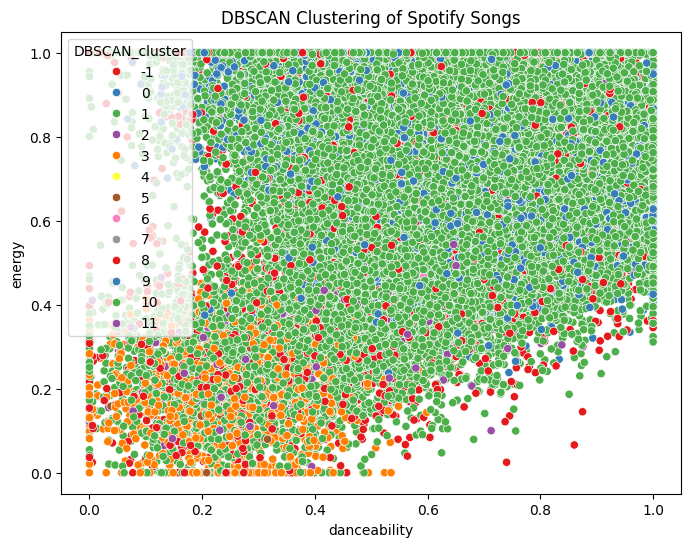

In [11]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['danceability'],
    y=df['energy'],
    hue=df['DBSCAN_cluster'],
    palette='Set1'
)

plt.title("DBSCAN Clustering of Spotify Songs")

plt.show()

⚠️ DBSCAN labels noise points as -1.
Silhouette score cannot be computed if all points are noise or if there is only one cluster, and usually we remove noise points before calculating the score.

| Score    | Quality   |
| -------- | --------- |
| >0.7     | Excellent |
| 0.5–0.7  | Good      |
| 0.25–0.5 | Weak      |
| <0.25    | Poor      |


In [13]:
# Import silhouette score metric
from sklearn.metrics import silhouette_score

# DBSCAN assigns -1 to noise points
# We remove those noise points before calculating the score

mask = df['DBSCAN_cluster'] != -1

# Apply the mask to remove noise samples
filtered_features = scaled_features[mask]
filtered_labels = df['DBSCAN_cluster'][mask]

# Calculate Silhouette Score
score = silhouette_score(filtered_features, filtered_labels)

print("Silhouette Score for DBSCAN:", score)

Silhouette Score for DBSCAN: 0.0756752119066673


To compute the Davies–Bouldin Index (DBI) for DBSCAN, the idea is similar to silhouette score, but we must again handle the noise points (-1) produced by DBSCAN.

⚠️ Important:
Davies–Bouldin Index requires at least 2 clusters, and noise points should be removed before calculating it.

Davies-Bouldin evaluation metric

| Value  | Meaning            |
| ------ | ------------------ |
| **0**  | Perfect clustering |
| **<1** | Good               |
| **>2** | Poor               |


In [14]:
# Import Davies-Bouldin evaluation metric
from sklearn.metrics import davies_bouldin_score

# DBSCAN assigns -1 to noise points (outliers)
# Remove those noise points before calculating the metric

mask = df['DBSCAN_cluster'] != -1

# Keep only clustered points
filtered_features = scaled_features[mask]
filtered_labels = df['DBSCAN_cluster'][mask]

# Calculate Davies-Bouldin Index
db_index = davies_bouldin_score(filtered_features, filtered_labels)

print("Davies–Bouldin Index for DBSCAN:", db_index)

Davies–Bouldin Index for DBSCAN: 1.1797783228398855
